In [36]:
# my 1st ever eda and feat engineering with model training. 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
test = pd.read_csv('titanic/test.csv')
train = pd.read_csv('titanic/train.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [38]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [39]:
merge = pd.concat( [train,test], keys=['train','test'])
merge

PassengerId  Survived  Pclass  \
train 0              1       0.0       3   
      1              2       1.0       1   
      2              3       1.0       3   
      3              4       1.0       1   
      4              5       0.0       3   
...                ...       ...     ...   
test  413         1305       NaN       3   
      414         1306       NaN       1   
      415         1307       NaN       3   
      416         1308       NaN       3   
      417         1309       NaN       3   

                                                        Name     Sex   Age  \
train 0                              Braund, Mr. Owen Harris    male  22.0   
      1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
      2                               Heikkinen, Miss. Laina  female  26.0   
      3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
      4                             Allen, Mr. William Henry    male  35.0   
...                                                      ...     ...   ...   
test  413                                 Spector, Mr. Woolf    male   NaN   
      414                       Oliva y Ocana, Dona. Fermina  female  39.0   
      415                       Saether, Mr. Simon Sivertsen    male  38.5   
      416                                Ware, Mr. Frederick    male   NaN   
      417                           Peter, Master. Michael J    male   NaN   

           SibSp  Parch              Ticket      Fare Cabin Embarked  
train 0        1      0           A/5 21171    7.2500   NaN        S  
      1        1      0            PC 17599   71.2833   C85        C  
      2        0      0    STON/O2. 3101282    7.9250   NaN        S  
      3        1      0              113803   53.1000  C123        S  
      4        0      0              373450    8.0500   NaN        S  
...          ...    ...                 ...       ...   ...      ...  
test  413      0      0           A.5. 3236    8.0500   NaN        S  
      414      0      0            PC 17758  108.9000  C105        C  
      415      0      0  SOTON/O.Q. 3101262    7.2500   NaN        S  
      416      0      0              359309    8.0500   NaN        S  
      417      1      1                2668   22.3583   NaN        C  

[1309 rows x 12 columns]

In [40]:
merge.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [41]:
merge.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

<Axes: xlabel='Survived', ylabel='Fare'>

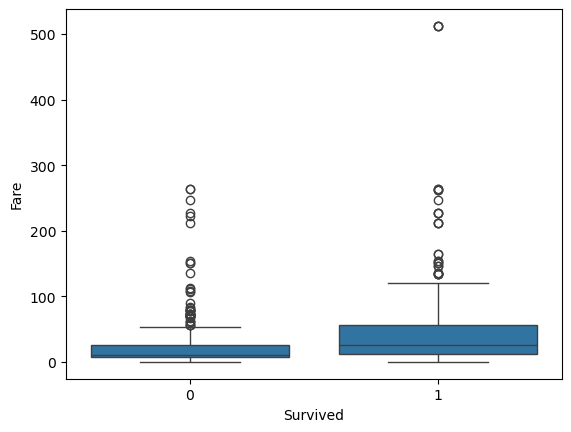

In [42]:
sns.boxplot(
    x='Survived',
    y='Fare',
    data=train
)

### Higher Fare -> Higher Class -> Higher Survival

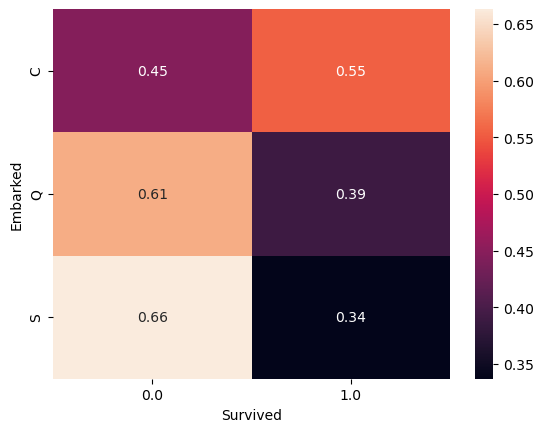

<Axes: xlabel='Embarked', ylabel='count'>

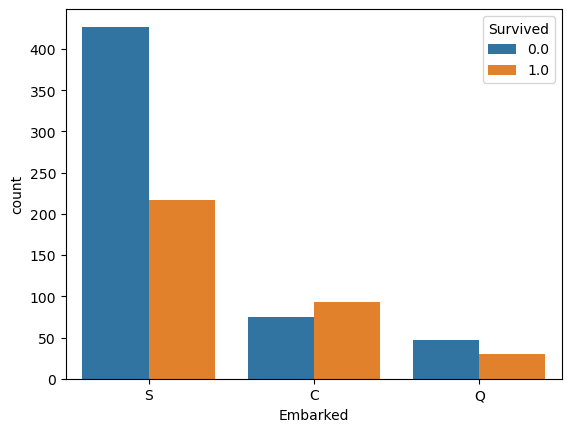

In [43]:
sns.heatmap(pd.crosstab(merge['Embarked'], merge['Survived'],    normalize='index'),annot=True)
plt.show()
sns.countplot(data=merge, x='Embarked', hue='Survived')


### Out of all 3 Ports, Port C had the highest survival rate and Port S had the lowest survival rate.

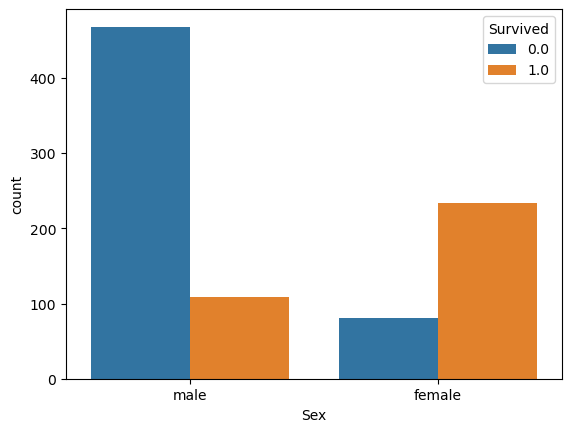

<Axes: xlabel='Survived', ylabel='Sex'>

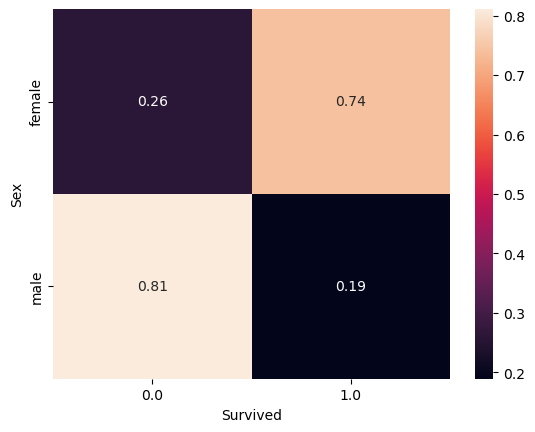

In [44]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=merge
)
plt.show()
# normalizing it, as the records for male and female aren't the same in amount.
sns.heatmap(pd.crosstab(merge['Sex'],merge['Survived'],normalize='index'), annot=True)

### Women had a higher survival rate compared to Men

<Axes: xlabel='Pclass', ylabel='Embarked'>

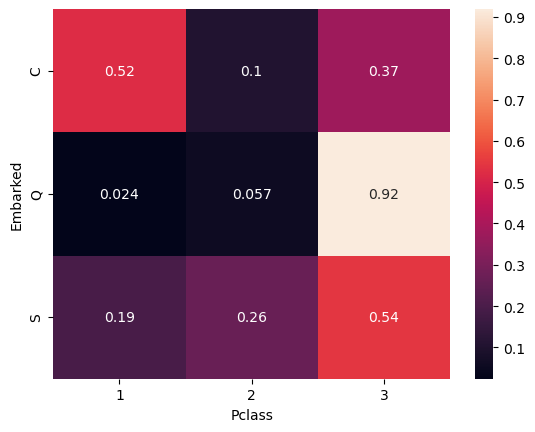

In [45]:
sns.heatmap(pd.crosstab(
    merge['Embarked'],
    merge['Pclass'], normalize='index'
), annot=True)

### Passengers embarking from Cherbourg (C) were disproportionately represented in First Class, with approximately 52% of passengers belonging to Pclass 1. In contrast, passengers embarking from Queenstown (Q) were overwhelmingly concentrated in Third Class (92%). Southampton (S) passengers were more mixed, although Third Class passengers still formed the majority (54%).

<Figure size 1200x800 with 0 Axes>

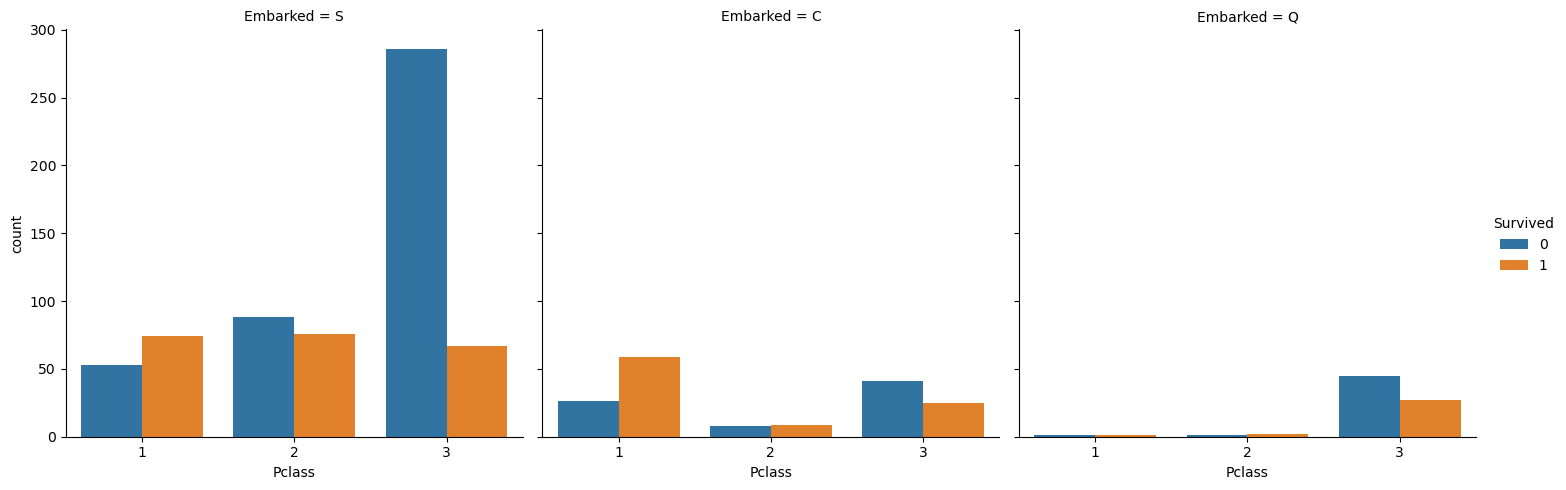

<Figure size 1200x800 with 0 Axes>

In [46]:
sns.catplot(
    x='Pclass',
    hue='Survived',
    col='Embarked',
    data=train,
    kind='count'
); plt.figure(figsize = (12,8))  #not much insight

<Axes: xlabel='Pclass', ylabel='Sex'>

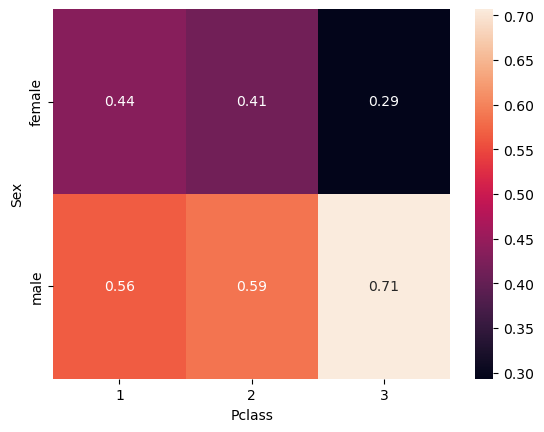

In [47]:
sns.heatmap(pd.crosstab(train['Sex'], train['Pclass'], normalize='columns'), annot=True)

In [48]:
merge['FamilySize'] = (
    merge['SibSp']
    + merge['Parch']
    + 1
)

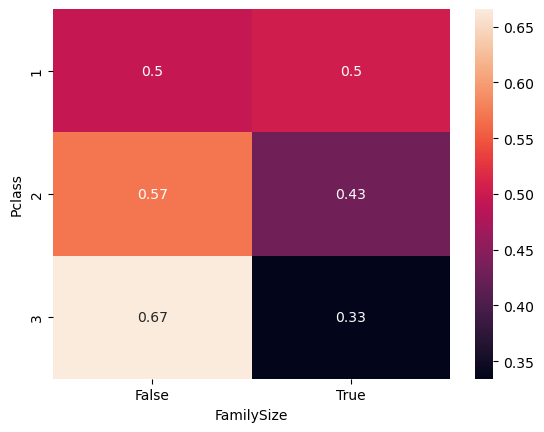

<Axes: xlabel='Pclass', ylabel='FamilySize'>

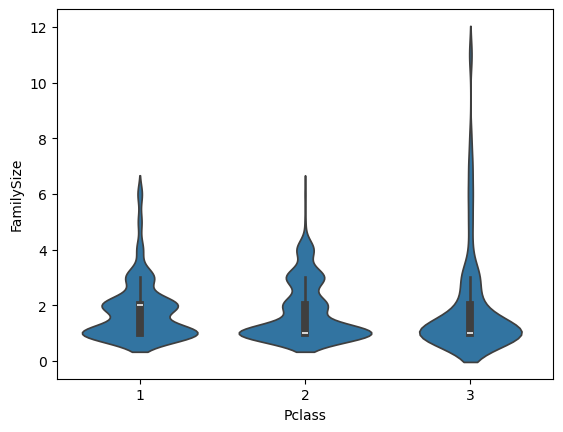

In [49]:
sns.heatmap(pd.crosstab(
    merge['Pclass'],
    merge['FamilySize'] > 1,
    normalize='index'
), annot=True)
plt.show()

sns.violinplot(
    x='Pclass',
    y='FamilySize',
    data=merge
)

### Third-class passengers were substantially more likely to travel alone compared to first-class passengers. Approximately two-thirds of third-class passengers travelled without accompanying family members, whereas first-class passengers were evenly split between solo and family travel.

<Axes: xlabel='Survived', ylabel='FamilySize'>

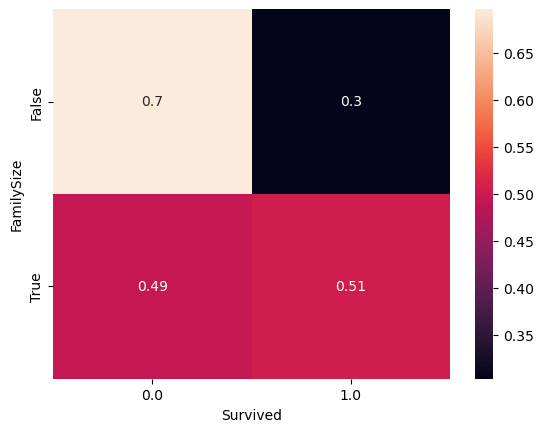

In [50]:
sns.heatmap(pd.crosstab(merge['FamilySize']>1, merge['Survived'], normalize='index'), annot=True)

In [51]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    merge['FamilySize'] > 1,
    merge['Survived']
)

chi2, p, dof, expected = chi2_contingency(table)
print(p)

1.9726543846517183e-09


In [52]:
merge['Sex'] = merge['Sex'].apply(lambda x: 0 if x=='male' else 1)
merge.Age = merge.Age.fillna(merge.Age.median())
merge

PassengerId  Survived  Pclass  \
train 0              1       0.0       3   
      1              2       1.0       1   
      2              3       1.0       3   
      3              4       1.0       1   
      4              5       0.0       3   
...                ...       ...     ...   
test  413         1305       NaN       3   
      414         1306       NaN       1   
      415         1307       NaN       3   
      416         1308       NaN       3   
      417         1309       NaN       3   

                                                        Name  Sex   Age  \
train 0                              Braund, Mr. Owen Harris    0  22.0   
      1    Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0   
      2                               Heikkinen, Miss. Laina    1  26.0   
      3         Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0   
      4                             Allen, Mr. William Henry    0  35.0   
...                                                      ...  ...   ...   
test  413                                 Spector, Mr. Woolf    0  28.0   
      414                       Oliva y Ocana, Dona. Fermina    1  39.0   
      415                       Saether, Mr. Simon Sivertsen    0  38.5   
      416                                Ware, Mr. Frederick    0  28.0   
      417                           Peter, Master. Michael J    0  28.0   

           SibSp  Parch              Ticket      Fare Cabin Embarked  \
train 0        1      0           A/5 21171    7.2500   NaN        S   
      1        1      0            PC 17599   71.2833   C85        C   
      2        0      0    STON/O2. 3101282    7.9250   NaN        S   
      3        1      0              113803   53.1000  C123        S   
      4        0      0              373450    8.0500   NaN        S   
...          ...    ...                 ...       ...   ...      ...   
test  413      0      0           A.5. 3236    8.0500   NaN        S   
      414      0      0            PC 17758  108.9000  C105        C   
      415      0      0  SOTON/O.Q. 3101262    7.2500   NaN        S   
      416      0      0              359309    8.0500   NaN        S   
      417      1      1                2668   22.3583   NaN        C   

           FamilySize  
train 0             2  
      1             2  
      2             1  
      3             2  
      4             1  
...               ...  
test  413           1  
      414           1  
      415           1  
      416           1  
      417           3  

[1309 rows x 13 columns]

In [53]:
pd.crosstab(
    merge['SibSp'],
    merge['Survived'],
    normalize='index'
)

Survived,0.0,1.0
SibSp,,
0,0.654605,0.345395
1,0.464115,0.535885
2,0.535714,0.464286
3,0.750000,0.250000
4,0.833333,0.166667
5,1.000000,0.000000
8,1.000000,0.000000


In [54]:
pd.crosstab(
    merge['Parch'],
    merge['Survived'],
    normalize='index'
)

Survived,0.0,1.0
Parch,,
0,0.656342,0.343658
1,0.449153,0.550847
2,0.500000,0.500000
3,0.400000,0.600000
4,1.000000,0.000000
5,0.800000,0.200000
6,1.000000,0.000000


<Axes: xlabel='Survived', ylabel='Sex-Pclass'>

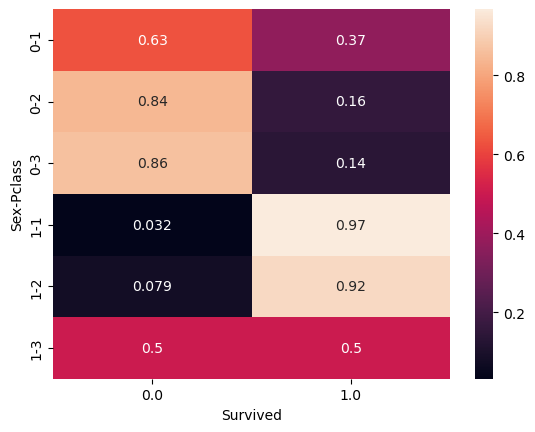

In [55]:
sns.heatmap(pd.crosstab(
    [merge['Sex'], merge['Pclass']],
    merge['Survived'],
    normalize='index'
), annot=True)


In [56]:
pd.crosstab(
    [merge['Embarked'], merge['Pclass']],
    merge['Survived'],
    normalize='index'
)

Survived              0.0       1.0
Embarked Pclass                    
C        1       0.305882  0.694118
         2       0.470588  0.529412
         3       0.621212  0.378788
Q        1       0.500000  0.500000
         2       0.333333  0.666667
         3       0.625000  0.375000
S        1       0.417323  0.582677
         2       0.536585  0.463415
         3       0.810198  0.189802

<Axes: xlabel='Survived', ylabel='Embarked-Pclass'>

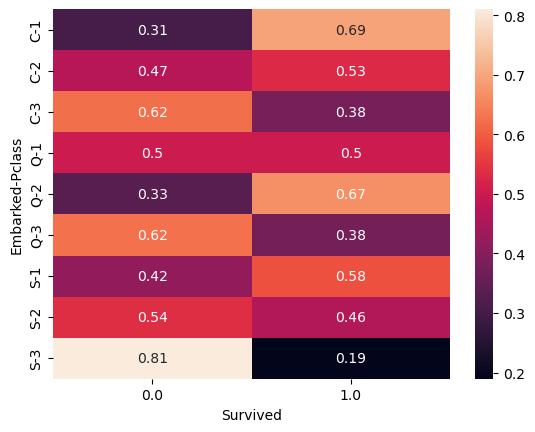

In [57]:
sns.heatmap(pd.crosstab(
    [merge['Embarked'], merge['Pclass']],
    merge['Survived'],
    normalize='index'
) , annot=True)

In [58]:
merge['Sex'].value_counts()

Sex
0    843
1    466
Name: count, dtype: int64

## Feat engineering. 

In [59]:
merge['Title'] = merge.Name.str.extract(f'([A-Za-z]+)\.', expand=False)
merge['Title'].value_counts()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_246798/3371472720.py:1: SyntaxWarning: invalid escape sequence '\.'
  merge['Title'] = merge.Name.str.extract(f'([A-Za-z]+)\.', expand=False)


Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

In [60]:
rare_titles = [
    'Rev','Dr','Col','Major',
    'Lady','Sir','Capt',
    'Countess','Jonkheer',
    'Dona','Don'
]

merge['Title'] = merge['Title'].replace(
    rare_titles,
    'Rare'
)

In [61]:
merge['CabinKnown'] = (
    merge.Cabin.notnull().astype(int)
)

In [62]:
pd.crosstab(
    merge['Title'],
    merge['Survived'],
    normalize='index'
)

Survived,0.0,1.0
Title,,
Master,0.425000,0.575000
Miss,0.302198,0.697802
Mlle,0.000000,1.000000
Mme,0.000000,1.000000
Mr,0.843327,0.156673
Mrs,0.208000,0.792000
Ms,0.000000,1.000000
Rare,0.652174,0.347826


In [144]:
merge.Age = merge.Age.fillna(
    merge.groupby('Title')['Age'].transform('median')
)
merge.Age

train  0      22.0
       1      38.0
       2      26.0
       3      35.0
       4      35.0
              ... 
test   413    28.0
       414    39.0
       415    38.5
       416    28.0
       417    28.0
Name: Age, Length: 1309, dtype: float64

In [145]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'Embarked',
    'FamilySize',
    'Title',
    'CabinKnown'
]
target = 'Survived'
train_df = merge.loc['train'].copy()
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'Title',
       'CabinKnown'],
      dtype='str')

In [146]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Impute missing 'Embarked' values in train_df with the mode from the 'merge' DataFrame
train_df['Embarked'].fillna(merge['Embarked'].mode()[0], inplace=True)

train_df.drop(columns=['Cabin','Ticket','SibSp','Parch','PassengerId','Name'], inplace=True)
train_df.columns
num = ['Age','Fare','FamilySize']
alpha = ['Pclass','Embarked','Title']

/tmp/ipykernel_246798/2382505725.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Embarked'].fillna(merge['Embarked'].mode()[0], inplace=True)


In [147]:
prepro = ColumnTransformer(
    transformers = [
        ('numeric',StandardScaler(), num),
        ('alpha',OneHotEncoder(),alpha)
    ]
)

        

pipeline= Pipeline([
    ('prep',prepro),
    ('clf',LogisticRegression())
]
                  )
X = train_df.drop(columns=['Survived'])
y = train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
    

In [148]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('alpha', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [158]:
train_len = train_df.shape[0]
test_df = merge.iloc[train_len:].copy()
test_df.columns
#y_pred = pipeline.predict(test_df)
#y_pred
test_df

PassengerId  Survived  Pclass  \
test 0            892       NaN       3   
     1            893       NaN       3   
     2            894       NaN       2   
     3            895       NaN       3   
     4            896       NaN       3   
...               ...       ...     ...   
     413         1305       NaN       3   
     414         1306       NaN       1   
     415         1307       NaN       3   
     416         1308       NaN       3   
     417         1309       NaN       3   

                                                  Name  Sex   Age  SibSp  \
test 0                                Kelly, Mr. James    0  34.5      0   
     1                Wilkes, Mrs. James (Ellen Needs)    1  47.0      1   
     2                       Myles, Mr. Thomas Francis    0  62.0      0   
     3                                Wirz, Mr. Albert    0  27.0      0   
     4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1  22.0      1   
...                                                ...  ...   ...    ...   
     413                            Spector, Mr. Woolf    0  28.0      0   
     414                  Oliva y Ocana, Dona. Fermina    1  39.0      0   
     415                  Saether, Mr. Simon Sivertsen    0  38.5      0   
     416                           Ware, Mr. Frederick    0  28.0      0   
     417                      Peter, Master. Michael J    0  28.0      1   

          Parch              Ticket      Fare Cabin Embarked  FamilySize  \
test 0        0              330911    7.8292   NaN        Q           1   
     1        0              363272    7.0000   NaN        S           2   
     2        0              240276    9.6875   NaN        Q           1   
     3        0              315154    8.6625   NaN        S           1   
     4        1             3101298   12.2875   NaN        S           3   
...         ...                 ...       ...   ...      ...         ...   
     413      0           A.5. 3236    8.0500   NaN        S           1   
     414      0            PC 17758  108.9000  C105        C           1   
     415      0  SOTON/O.Q. 3101262    7.2500   NaN        S           1   
     416      0              359309    8.0500   NaN        S           1   
     417      1                2668   22.3583   NaN        C           3   

           Title  CabinKnown  
test 0        Mr           0  
     1       Mrs           0  
     2        Mr           0  
     3        Mr           0  
     4       Mrs           0  
...          ...         ...  
     413      Mr           0  
     414    Rare           1  
     415      Mr           0  
     416      Mr           0  
     417  Master           0  

[418 rows x 15 columns]

In [157]:
test_df.dropna(inplace=True)

test_ids = test_df['PassengerId']
cols_to_drop = [
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin',
    'SibSp',
    'Parch',
    'Survived'
]

test_df = test_df.drop(columns=cols_to_drop)
test_df

,,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title,CabinKnown


In [151]:
test_df.isnull().sum()
test_df

,,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title,CabinKnown


In [154]:
pred = pipeline.predict(test_df)

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by StandardScaler.

In [153]:
pred

array([0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
       0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0.,
       1., 0., 1., 1., 0.

<Axes: ylabel='count'>

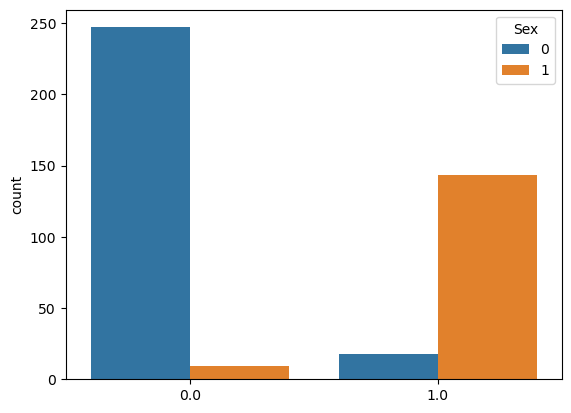

In [128]:
test_df['pred'] = pred
test_df['PassengerId'] = test_ids
sns.countplot(x=pred, hue='Sex', data=test_df)

<Axes: xlabel='PassengerId', ylabel='pred'>

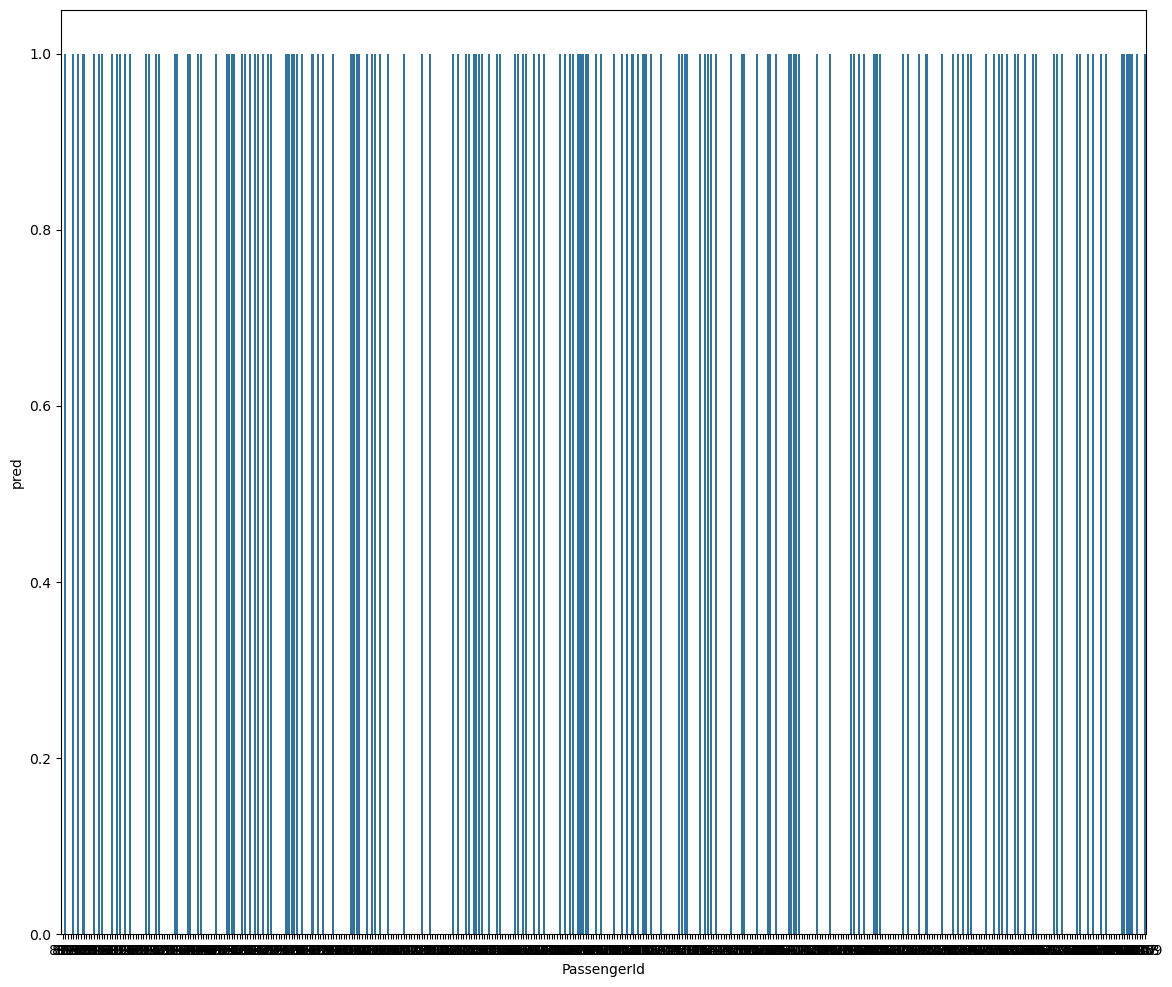

In [130]:
plt.figure(figsize=(14,12))
sns.barplot(data=test_df, x='PassengerId', y = 'pred')

In [137]:
print(len(pred))
print(len(test_df))
print(len(test_ids))
test_ids.pop()

417
417
418


TypeError: Series.pop() missing 1 required positional argument: 'item'